In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path='/content/drive/MyDrive/insurance.csv'
df=pd.read_csv(file_path)
print(df)

      age     sex     bmi  children smoker     region      charges
0      19  female  27.900         0    yes  southwest  16884.92400
1      18    male  33.770         1     no  southeast   1725.55230
2      28    male  33.000         3     no  southeast   4449.46200
3      33    male  22.705         0     no  northwest  21984.47061
4      32    male  28.880         0     no  northwest   3866.85520
...   ...     ...     ...       ...    ...        ...          ...
1333   50    male  30.970         3     no  northwest  10600.54830
1334   18  female  31.920         0     no  northeast   2205.98080
1335   18  female  36.850         0     no  southeast   1629.83350
1336   21  female  25.800         0     no  southwest   2007.94500
1337   61  female  29.070         0    yes  northwest  29141.36030

[1338 rows x 7 columns]


In [ ]:
print(df.head())
print(df.shape)

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
(1338, 7)


In [ ]:
print(df.isnull().sum())

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


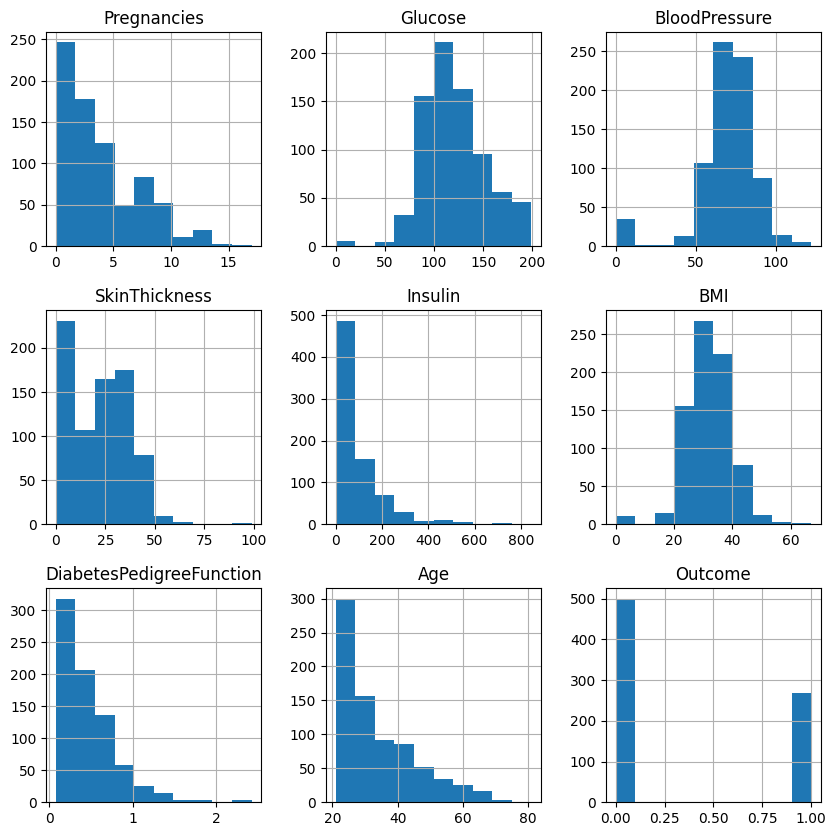

In [ ]:
df.hist(figsize=(10,10))
plt.show()

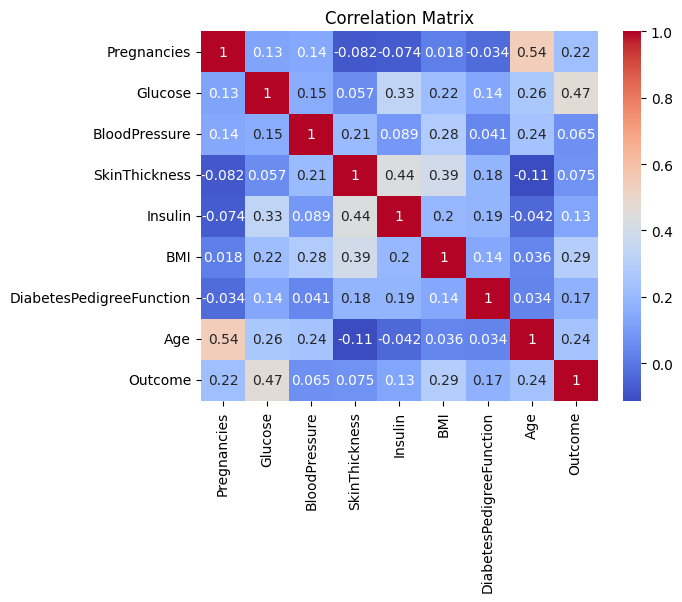

In [ ]:
corr_matrix=df.corr()
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

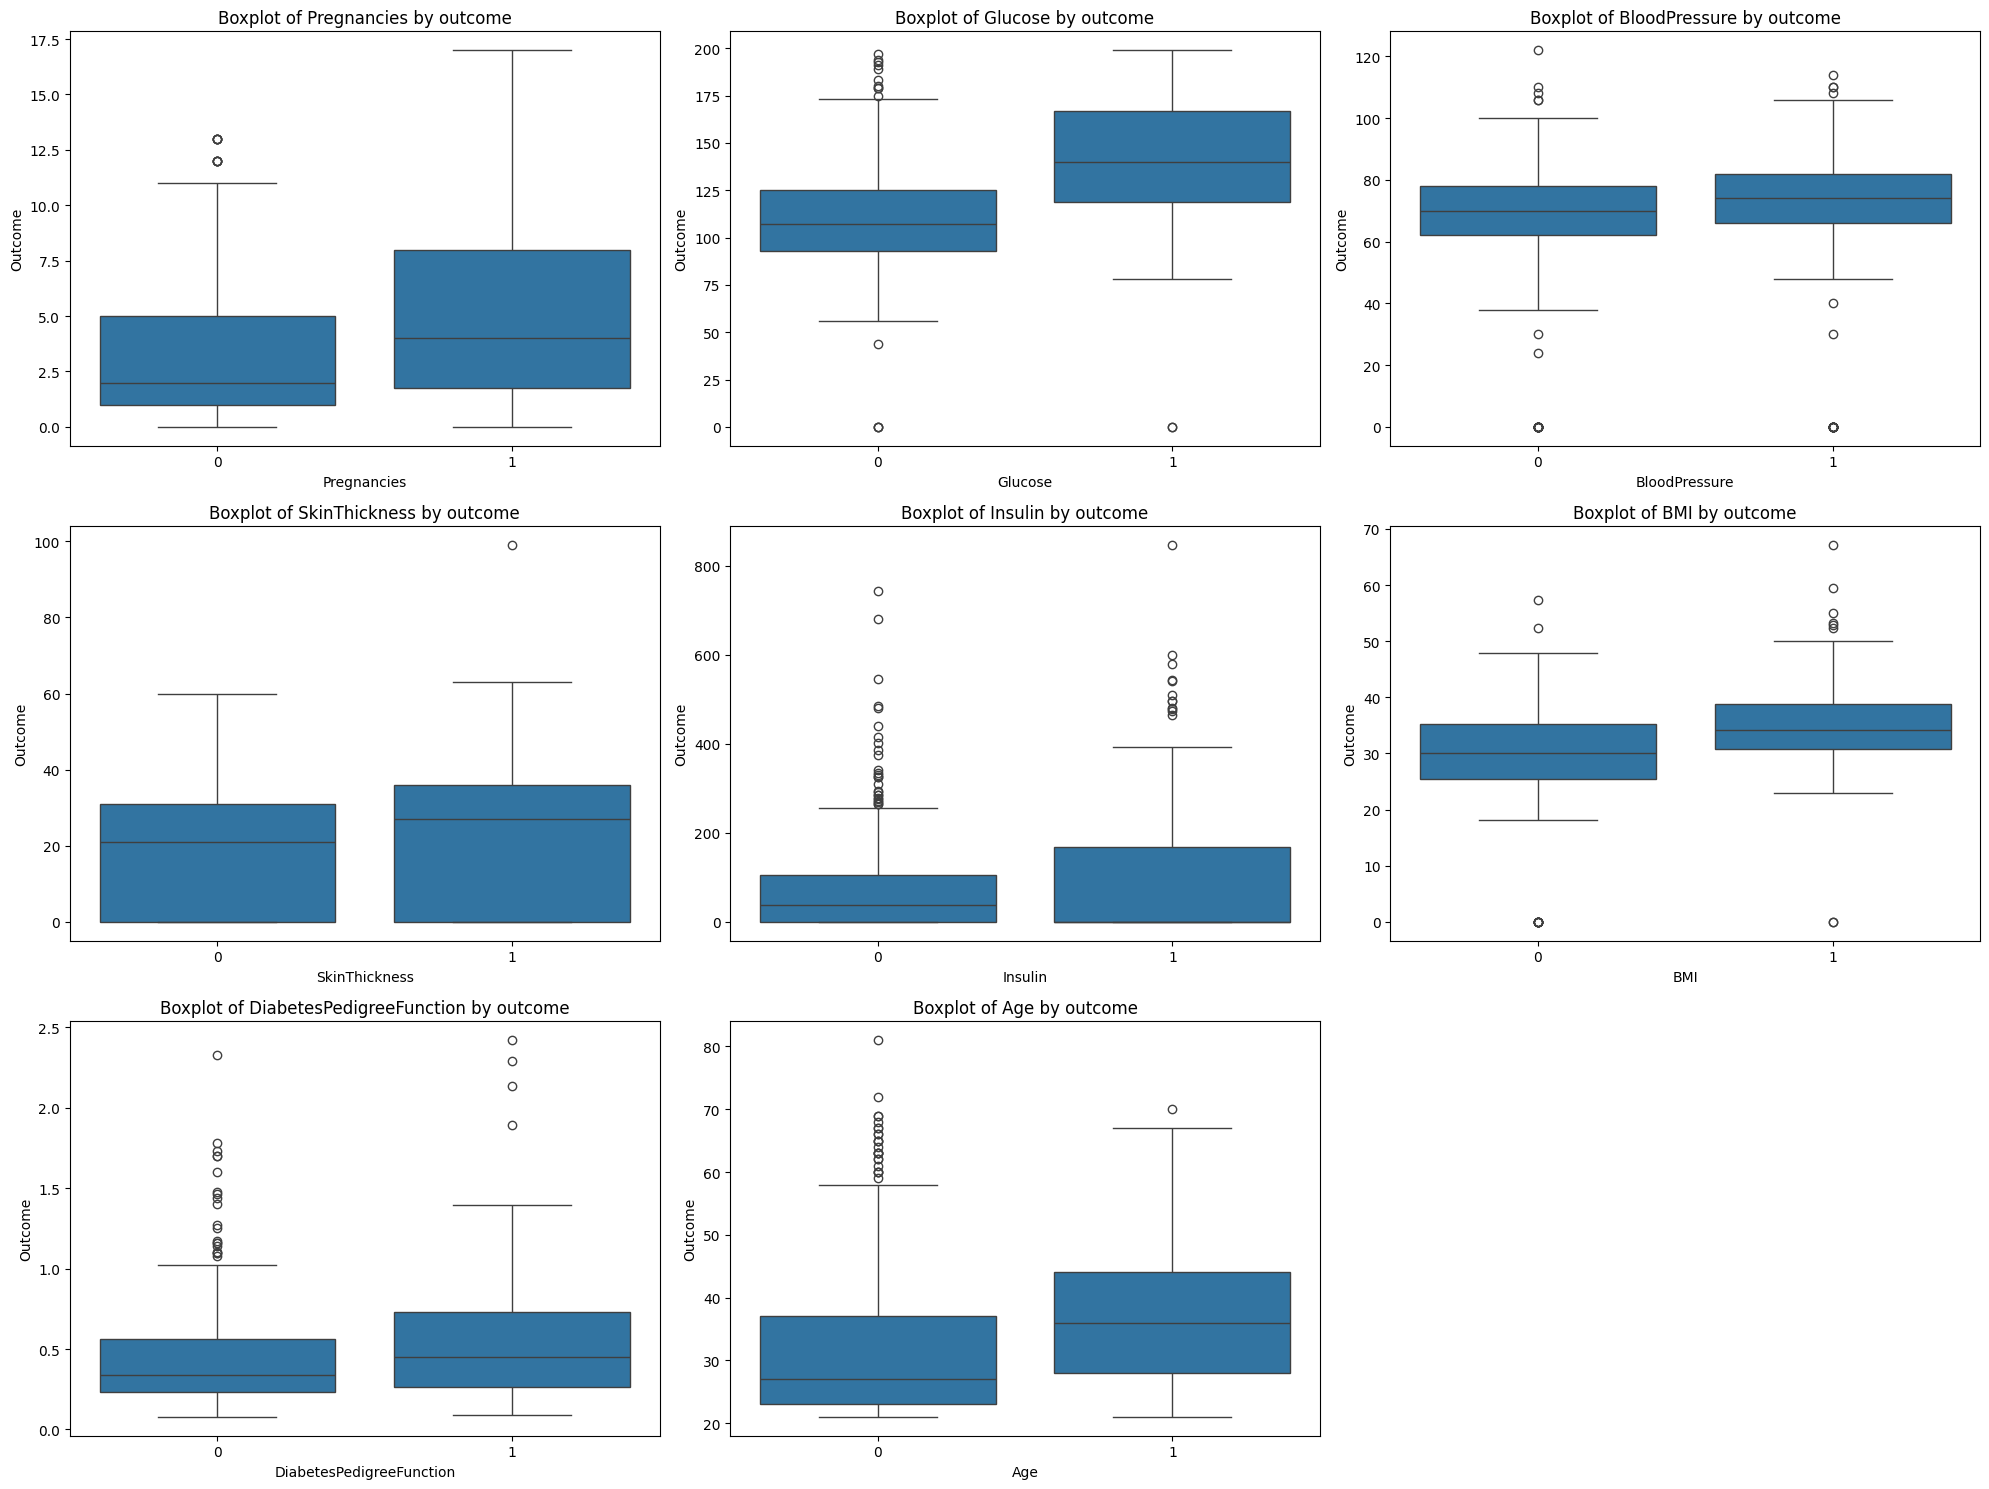

In [ ]:
features=['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age']
target='Outcome'
plt.figure(figsize=(20,15))

for i,feature in enumerate(features,1):
  plt.subplot(3,3,i)
  sns.boxplot(x='Outcome',y=feature,data=df)
  plt.title(f'Boxplot of {feature} by outcome')
  plt.tight_layout()
  plt.xlabel(feature)
  plt.ylabel(target)
plt.show()

 Scatter Plot of Glucose vs BMI by Outcome 


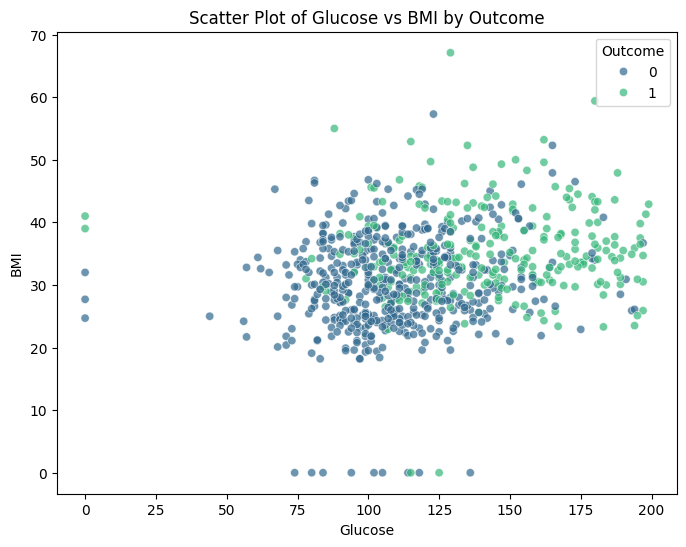

In [ ]:
print(" Scatter Plot of Glucose vs BMI by Outcome ")
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Glucose', y='BMI', hue='Outcome', data=df, palette='viridis', alpha=0.7)
plt.title('Scatter Plot of Glucose vs BMI by Outcome')
plt.xlabel('Glucose')
plt.ylabel('BMI')
plt.show()

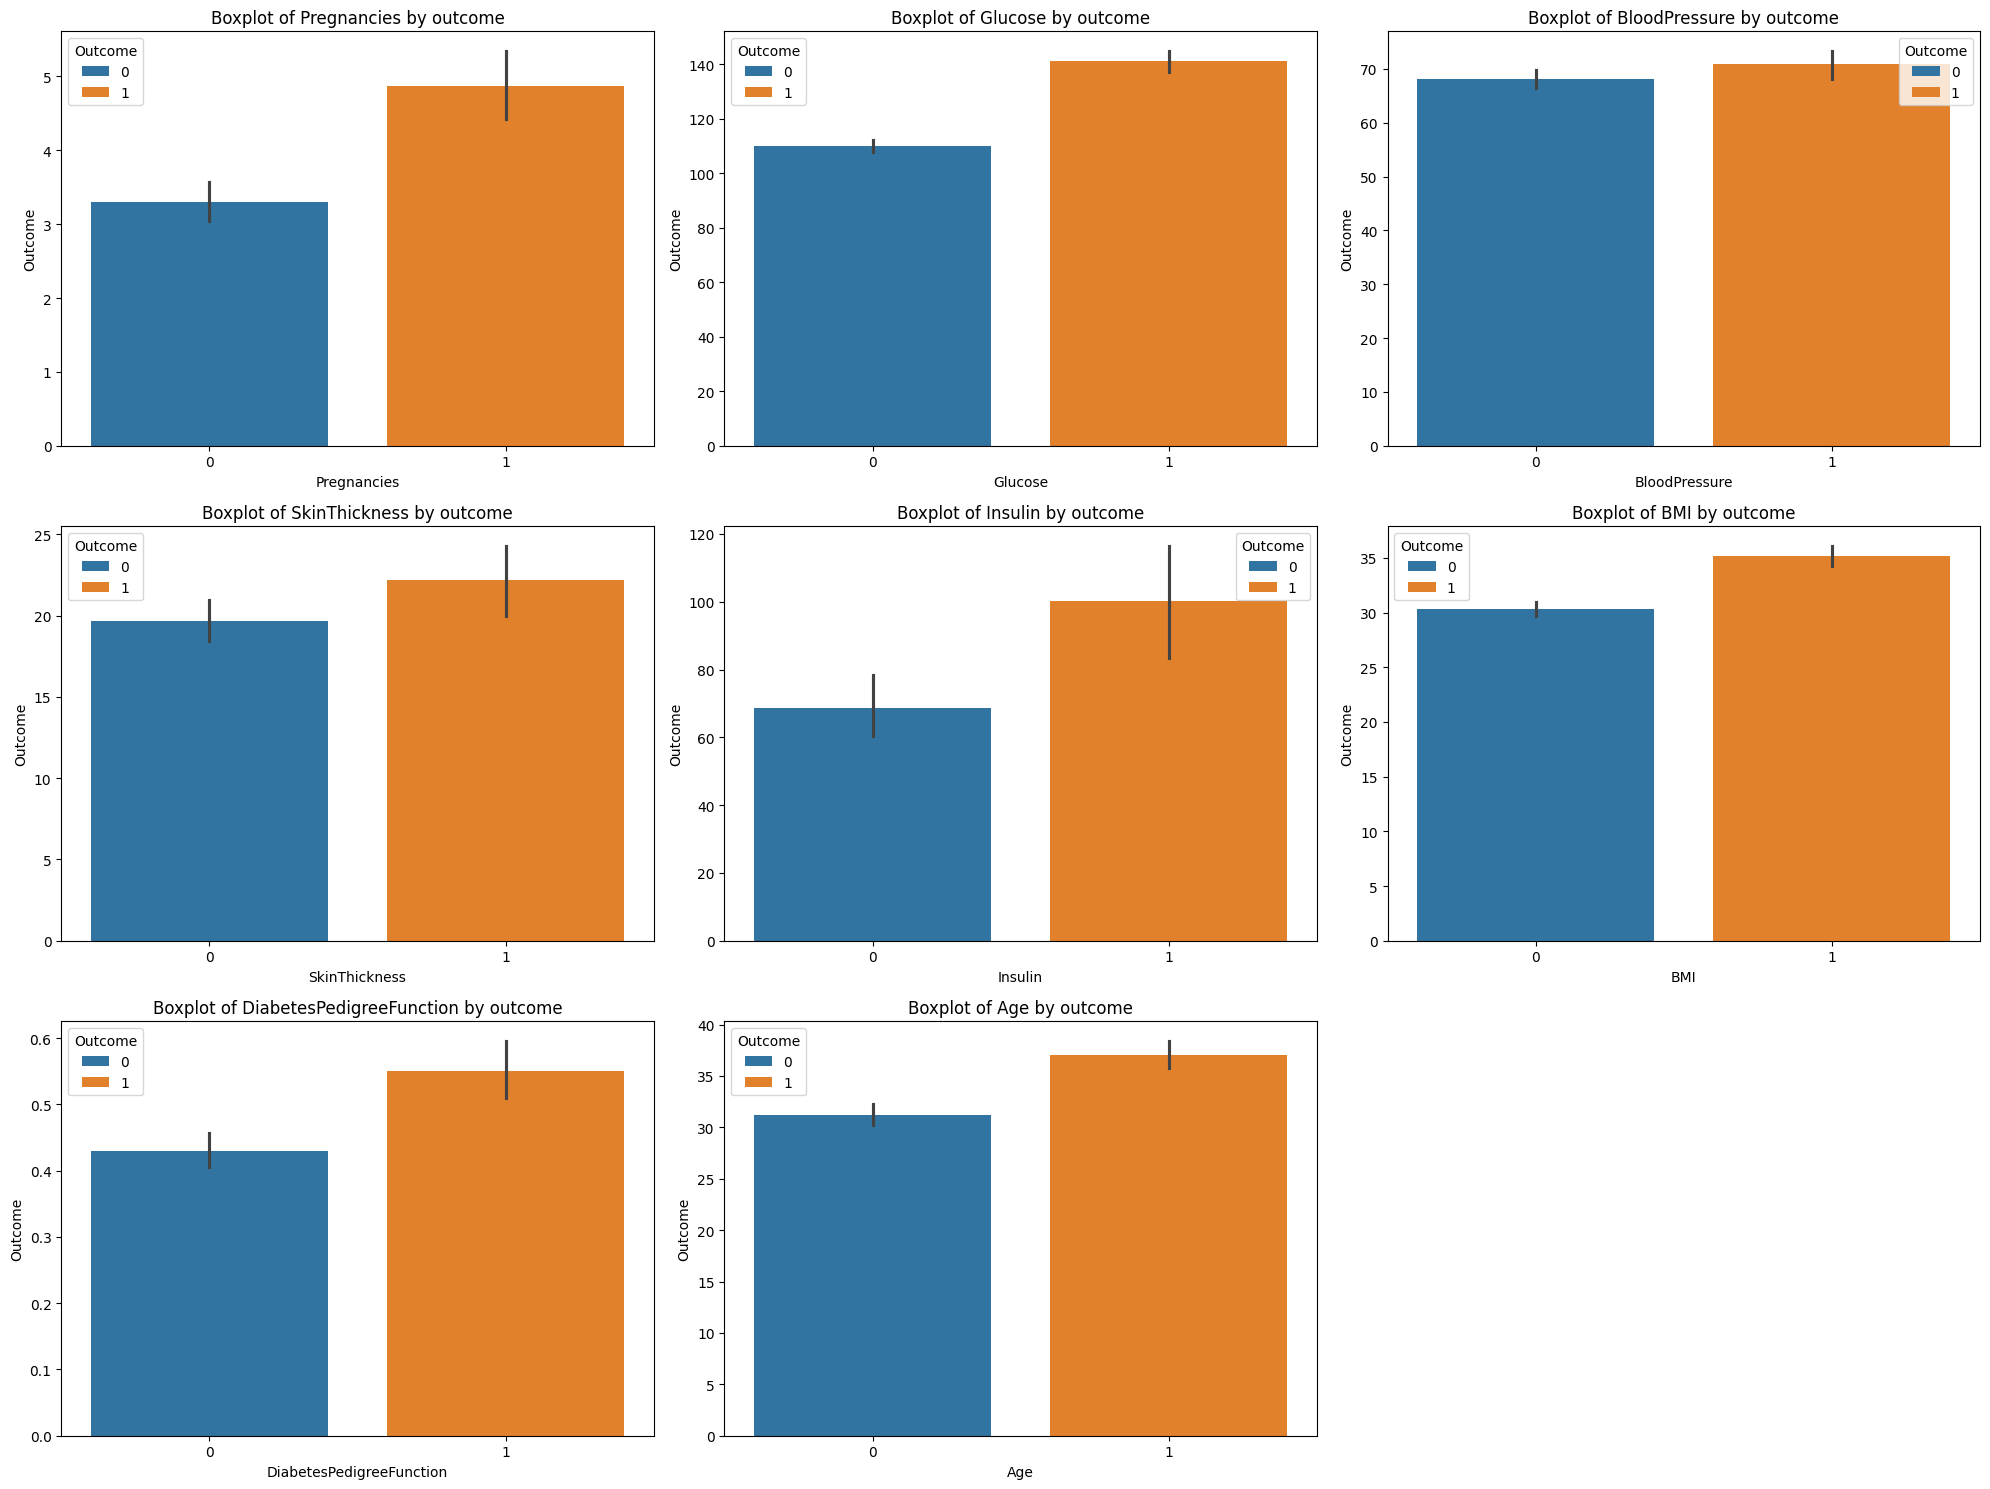

In [ ]:
features=['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age']
target='Outcome'
plt.figure(figsize=(20,15))

for i,feature in enumerate(features,1):
  plt.subplot(3,3,i)
  sns.barplot(x='Outcome',y=feature,data=df,hue='Outcome')
  plt.title(f'Boxplot of {feature} by outcome')
  plt.tight_layout()
  plt.xlabel(feature)
  plt.ylabel(target)
plt.show()

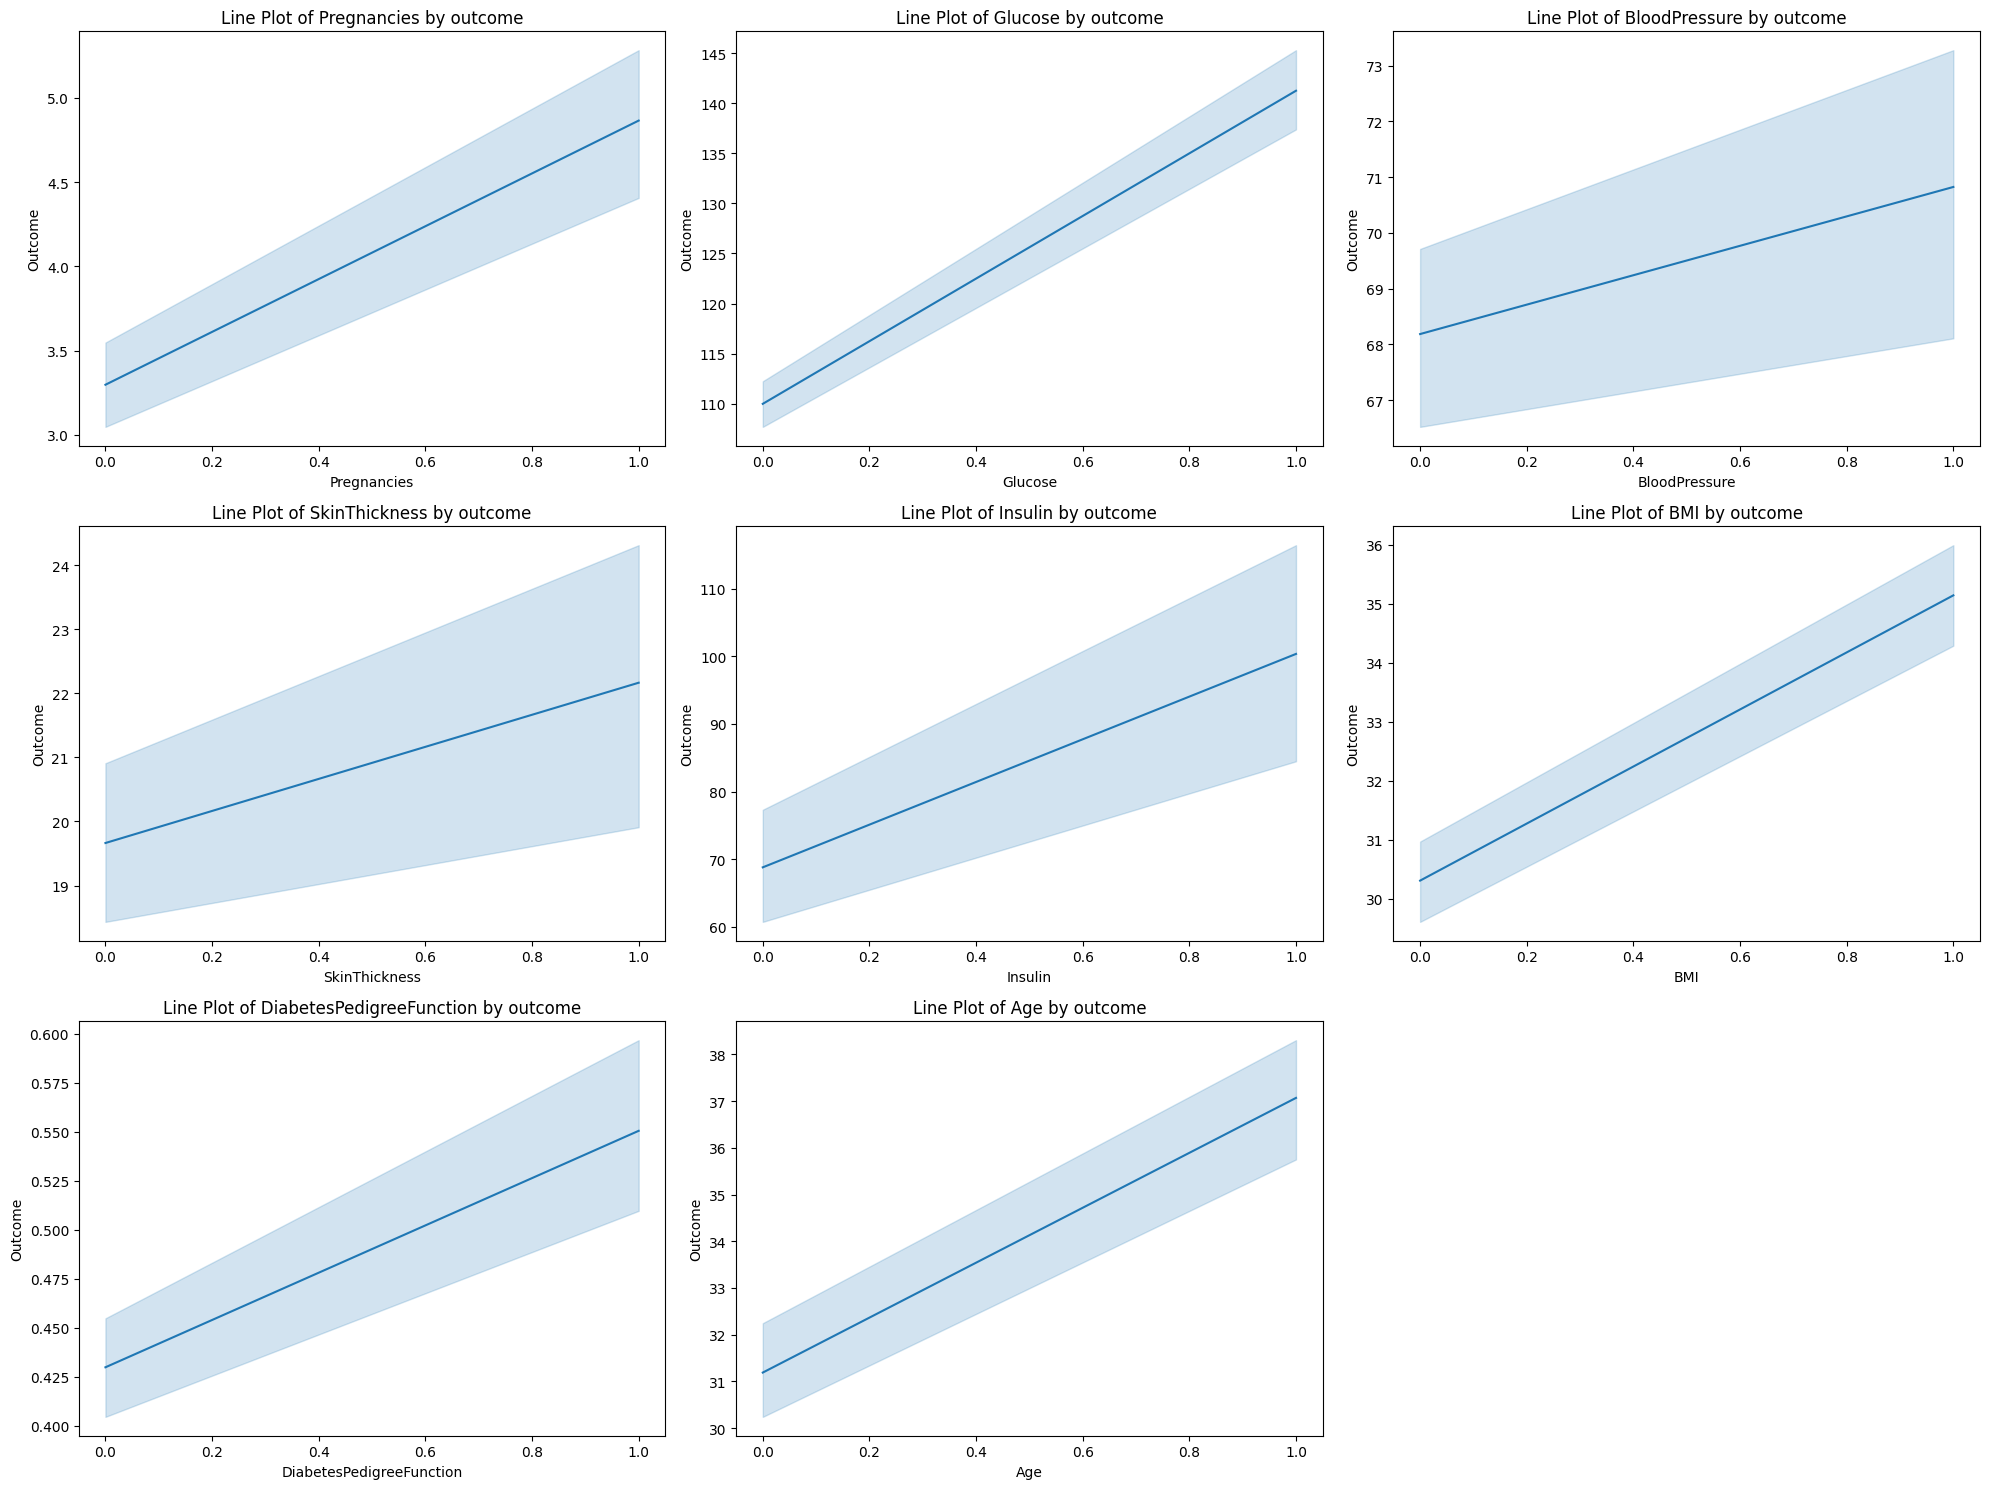

In [ ]:
features=['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age']
target='Outcome'
plt.figure(figsize=(20,15))

for i,feature in enumerate(features,1):
  plt.subplot(3,3,i)
  sns.lineplot(x='Outcome',y=feature,data=df)
  plt.title(f'Line Plot of {feature} by outcome')
  plt.tight_layout()
  plt.xlabel(feature)
  plt.ylabel(target)
plt.show()

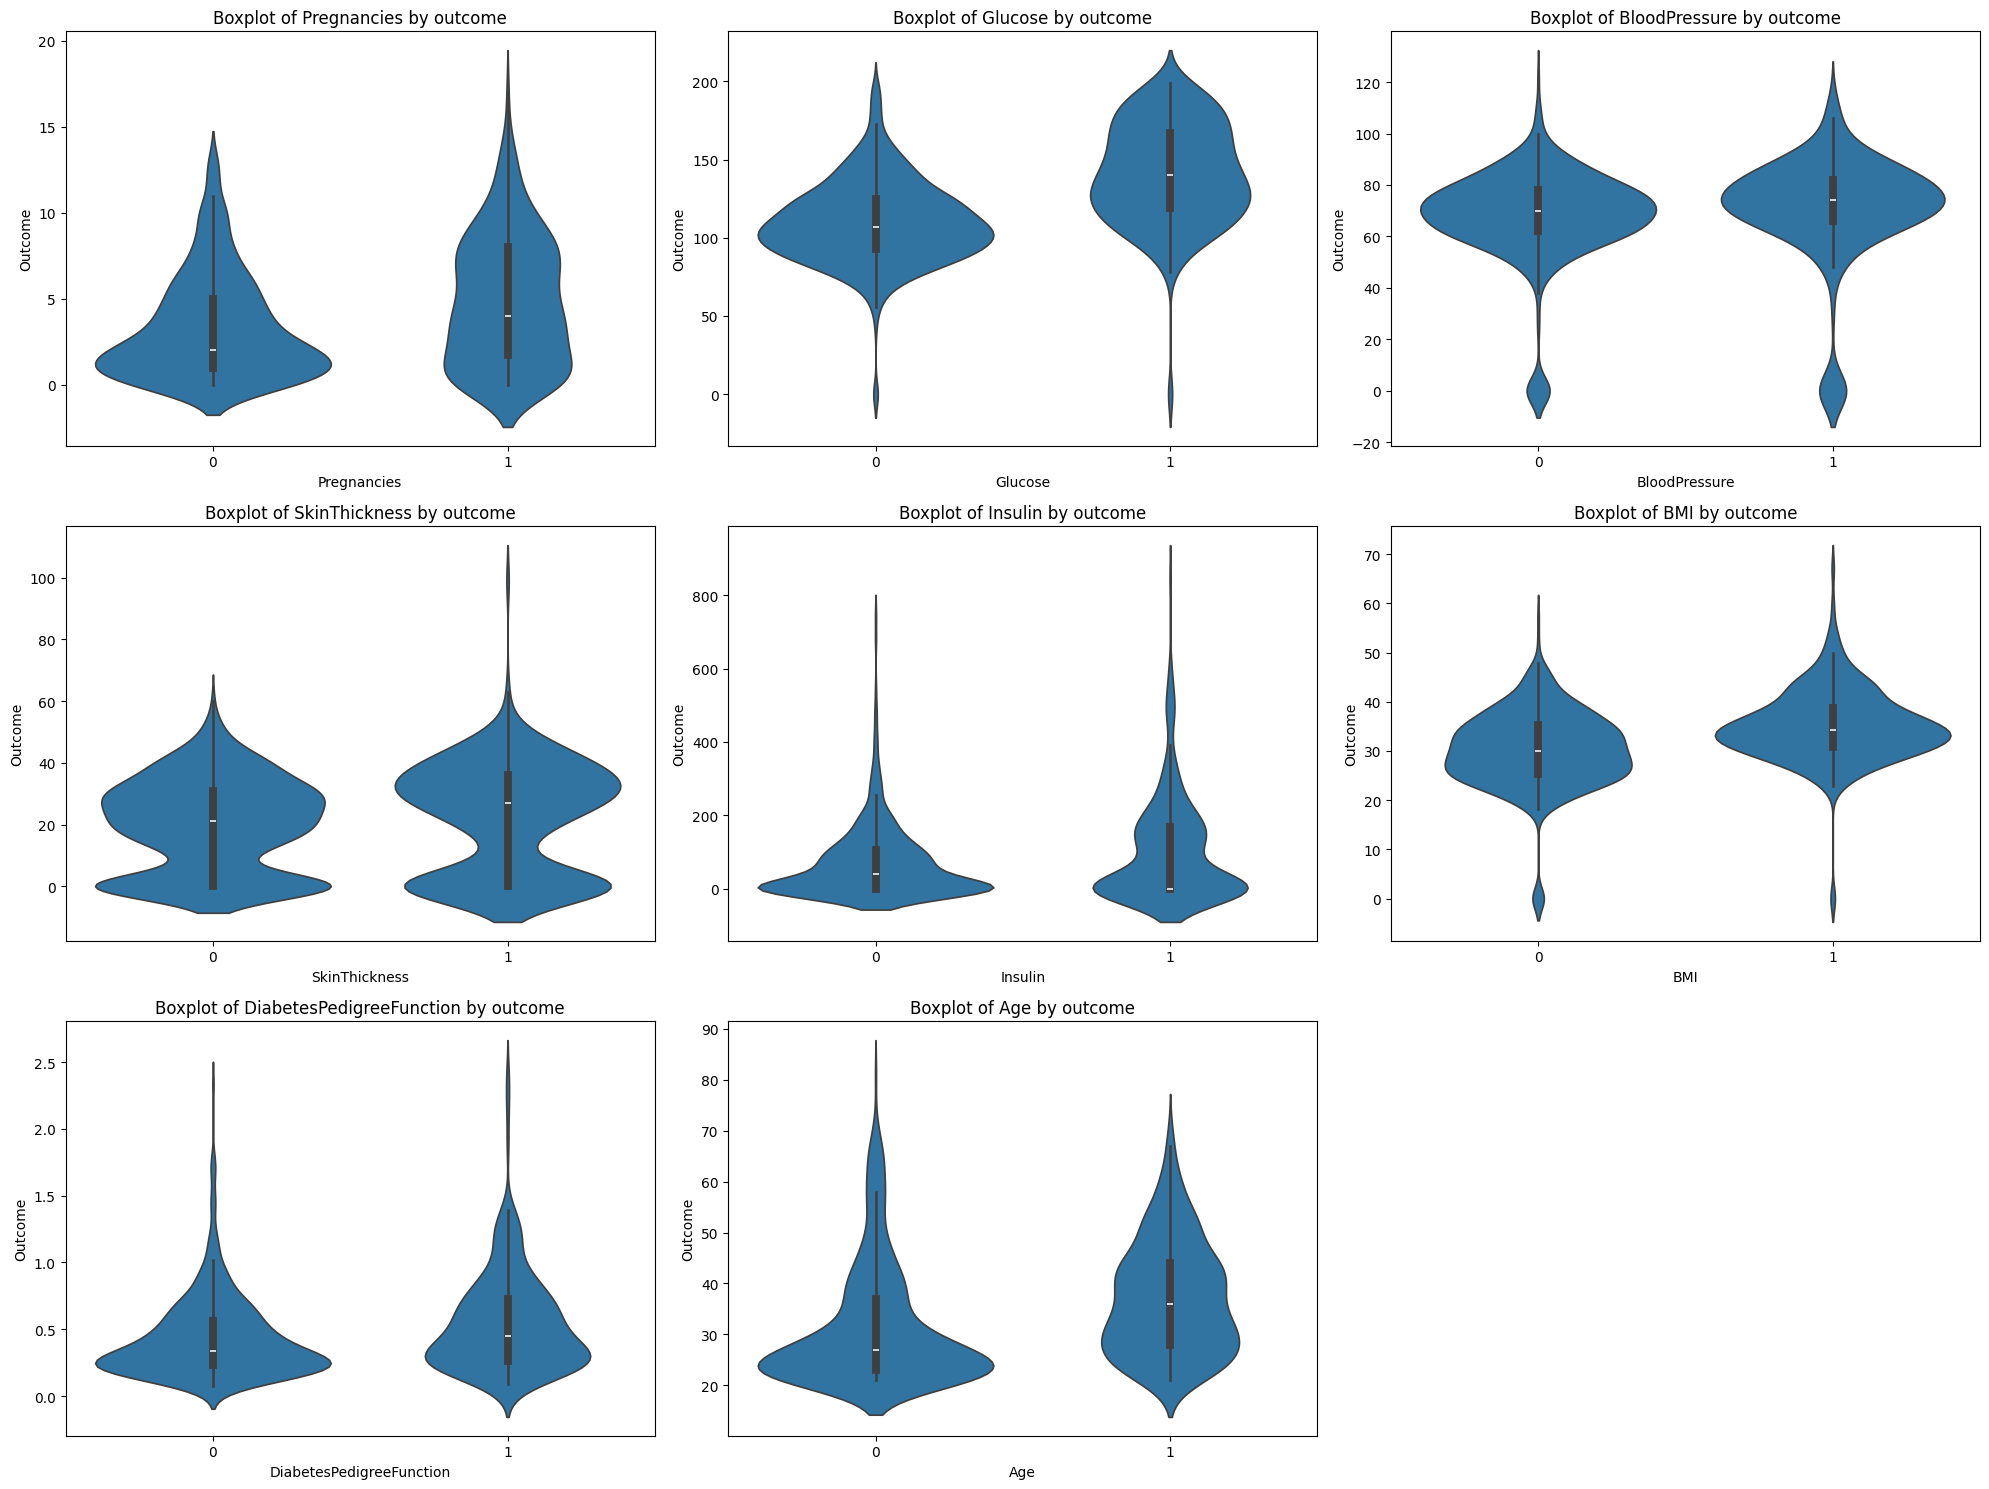

In [ ]:
features=['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age']
target='Outcome'
plt.figure(figsize=(20,15))

for i,feature in enumerate(features,1):
  plt.subplot(3,3,i)
  sns.violinplot(x='Outcome',y=feature,data=df)
  plt.title(f'Boxplot of {feature} by outcome')
  plt.tight_layout()
  plt.xlabel(feature)
  plt.ylabel(target)
plt.show()

In [ ]:
x=df.drop('Outcome',axis=1)
y=df['Outcome']

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.fit_transform(x_test)

In [ ]:
lr=LogisticRegression()
lr.fit(x_train,y_train)

LogisticRegression()

In [ ]:
y_pred=lr.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
accuracy=accuracy_score(y_test,y_pred)
print("Logistic Regression Accuracy:",accuracy)

Logistic Regression Accuracy: 0.7857142857142857


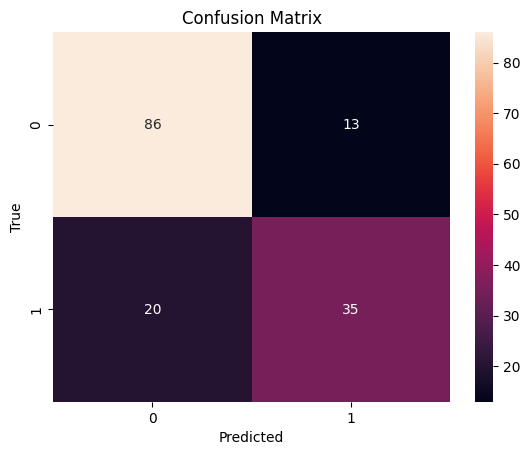

In [ ]:
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

accuracy=35+86/35+86+20+13

In [ ]:
def predict_outcome():
  featuress=[]
  for col in x.columns:
    value=float(input(f"Enter the value for {col}: "))
    featuress.append(value)

  featuress=np.array(featuress).reshape(1,-1)
  featuress=scaler.transform(featuress)
  prediction=lr.predict(featuress)
  if (prediction[0]==1):
    print("DIABETIC")
  else :
    print("NOT DIABETIC")

In [ ]:
predict_outcome()

Enter the value for Pregnancies: 23
Enter the value for Glucose: 467
Enter the value for BloodPressure: 54
Enter the value for SkinThickness: 32
Enter the value for Insulin: 46
Enter the value for BMI: 66
Enter the value for DiabetesPedigreeFunction: 44
Enter the value for Age: 33
DIABETIC


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
